<a href="https://colab.research.google.com/github/catarina1532/avcad/blob/main/avcad_ex9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PCA, PCoA and LDA using the EFIplus_medit dataset

##1. Principal Component Analysis (PCA)

***prompt***: run PCA on standardized quantitative environmental variables for Douro, Tejo, Mondego and Minho basins and produce a biplot colored by catchment_name

In [14]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
EFI = pd.read_csv('EFIplus_medit.csv', sep=';')

# Select only sites from the required catchments
basins = ['Douro', 'Tejo', 'Mondego', 'Minho']
EFI = EFI[EFI['Catchment_name'].isin(basins)]

# Select quantitative environmental variables
env_vars = [
    'Altitude',
    'Actual_river_slope',
    'Elevation_mean_catch',
    'prec_ann_catch',
    'temp_ann',
    'temp_jan',
    'temp_jul'
]

df = EFI[env_vars + ['Catchment_name']].dropna()

# Standardize variables
X = StandardScaler().fit_transform(df[env_vars])

# PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X)

pca_df = pd.DataFrame(scores, columns=['PC1', 'PC2'])
pca_df['Catchment_name'] = df['Catchment_name'].values

PCA reduces the multidimensional environmental dataset into two main synthetic gradients (PC1 and PC2) that summarize most of the environmental variability among sites. This allows visualization of how sampling sites from different catchments are distributed in environmental space.

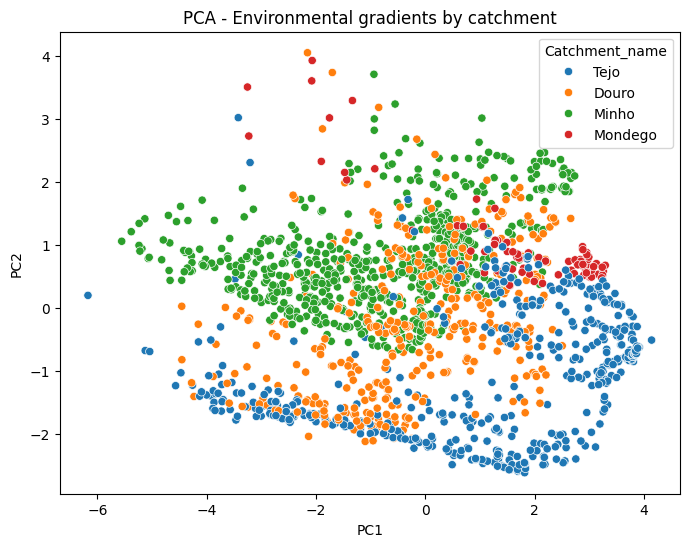

In [16]:
# PCA biplot (sites)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Catchment_name'
)

plt.title('PCA - Environmental gradients by catchment')
plt.show()

The PCA scatterplot shows whether sites cluster according to catchment. Separation between groups suggests that environmental conditions differ systematically among basins, while overlap indicates shared environmental characteristics.

##2. Principal Coordinate Analysis (PCoA)

***prompt***: compute a euclidean distance matrix and run PCoA to project sampling sites into two dimensions, visualizing results by catchment_name

In [17]:
from sklearn.metrics import pairwise_distances
from sklearn.manifold import MDS

# Distance matrix (Q-mode analysis)
dist_matrix = pairwise_distances(X, metric='euclidean')

# PCoA via classical MDS
pcoa = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = pcoa.fit_transform(dist_matrix)

pcoa_df = pd.DataFrame(coords, columns=['Axis1', 'Axis2'])
pcoa_df['Catchment_name'] = df['Catchment_name'].values

PCoA represents similarities among sites based directly on environmental distances rather than variance decomposition. This makes it more aligned with ecological dissimilarity interpretation compared to PCA.

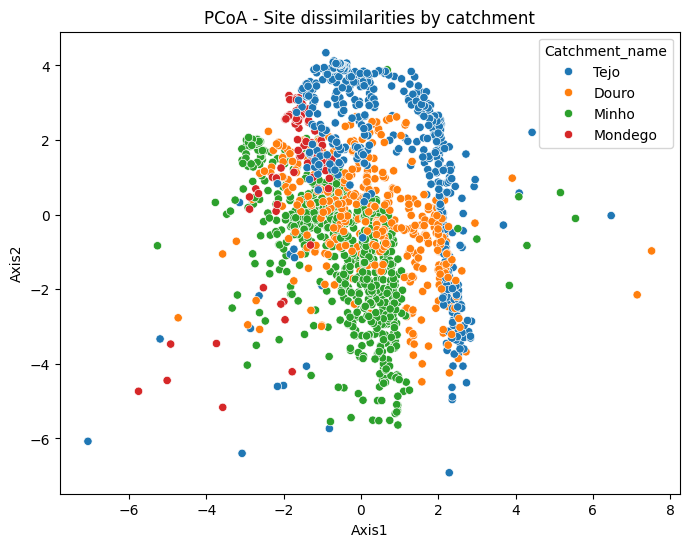

In [18]:
# PCoA plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pcoa_df,
    x='Axis1',
    y='Axis2',
    hue='Catchment_name'
)

plt.title('PCoA - Site dissimilarities by catchment')
plt.show()

The PCoA plot visualizes how ecologically similar or dissimilar sites are based on environmental distances. Clusters indicate groups of sites with similar environmental conditions, while separation indicates distinct ecological profiles among catchments.

##3. Linear Discriminant Analysis (LDA)

***prompt***: run linear discriminant analysis using environmental variables to classify sites into catchment_name groups and produce a discriminant biplot of the first two discriminant functions

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

X = df[env_vars].values
y = df['Catchment_name'].values

lda = LDA(n_components=2)
lda_scores = lda.fit_transform(X, y)

lda_df = pd.DataFrame(lda_scores, columns=['LD1', 'LD2'])
lda_df['Catchment_name'] = y

LDA finds linear combinations of environmental variables that maximize separation between predefined catchments. Unlike PCA and PCoA, it is a supervised method because it uses group labels.

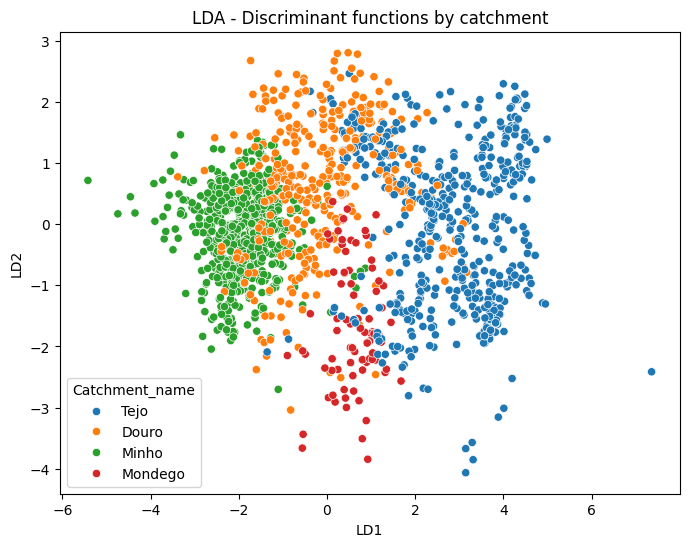

In [20]:
# LDA plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=lda_df,
    x='LD1',
    y='LD2',
    hue='Catchment_name'
)

plt.title('LDA - Discriminant functions by catchment')
plt.show()

The LDA plot shows how well environmental variables discriminate between catchments. Strong separation indicates that environmental conditions are sufficiently distinct to classify river basins based on their ecological profiles.

**Conclusion**

- PCA: structure/variance
- PCoA: ecological dissimilarity
- LDA: classification/group separation